In [85]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, KFold, cross_val_score
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from imblearn.over_sampling import SMOTE


# EDA

In [86]:
data = pd.read_csv('obes.csv')
print(f"Total dataset {data.shape[0]} baris dan {data.shape[1]} kolom.")
data.head()

Total dataset 2182 baris dan 17 kolom.


,Gender,Age,Height (m),Weight (kg),Family history of overweight,High caloric food consumption,Vegetable consumption frequency,Daily main meals frequency,Between-meal food consumption frequency,Smoking,Alcohol intake,Daily water intake,Monitor calories,Physical exercise,Daily device usage duration,Mode of transportation,Obesity level
0,Male,29,1.65,101.0,Yes,Yes,Sometimes,Three,Frequently,No,I do not drink,Between 1 and 2 L,No,I do not have,More than 5 hours,Private Car,Obesity_Type_II
1,Female,25,1.65,53.0,No,No,Always,Three,Always,No,I do not drink,Between 1 and 2 L,No,Almost Everyday,More than 5 hours,Public Transportation,Normal_Weight
2,Male,23,1.70,70.0,No,No,Always,Between 1-2,Sometimes,Yes,Sometimes,Less than a liter,No,I do not have,More than 5 hours,Public Transportation,Normal_Weight
3,Male,22,1.68,112.0,Yes,Yes,Sometimes,Three,Frequently,No,I do not drink,Between 1 and 2 L,No,I do not have,More than 5 hours,Public Transportation,Obesity_Type_II
4,Male,19,1.75,67.0,No,Yes,Always,Three,Sometimes,Yes,I do not drink,Between 1 and 2 L,No,2 or 4 days,3-5 hours,Bike,Normal_Weight


In [87]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2182 entries, 0 to 2181
Data columns (total 17 columns):
 #   Column                                   Non-Null Count  Dtype  
---  ------                                   --------------  -----  
 0   Gender                                   2182 non-null   object 
 1   Age                                      2182 non-null   int64  
 2   Height (m)                               2182 non-null   float64
 3   Weight (kg)                              2182 non-null   float64
 4   Family history of overweight             2182 non-null   object 
 5   High caloric food consumption            2182 non-null   object 
 6   Vegetable consumption frequency          2182 non-null   object 
 7   Daily main meals frequency               2182 non-null   object 
 8   Between-meal food consumption frequency  2182 non-null   object 
 9   Smoking                                  2182 non-null   object 
 10  Alcohol intake                           2182 no

C:\Users\hp\AppData\Local\Temp\ipykernel_4444\4153213174.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='Obesity level', data=data, palette='viridis')


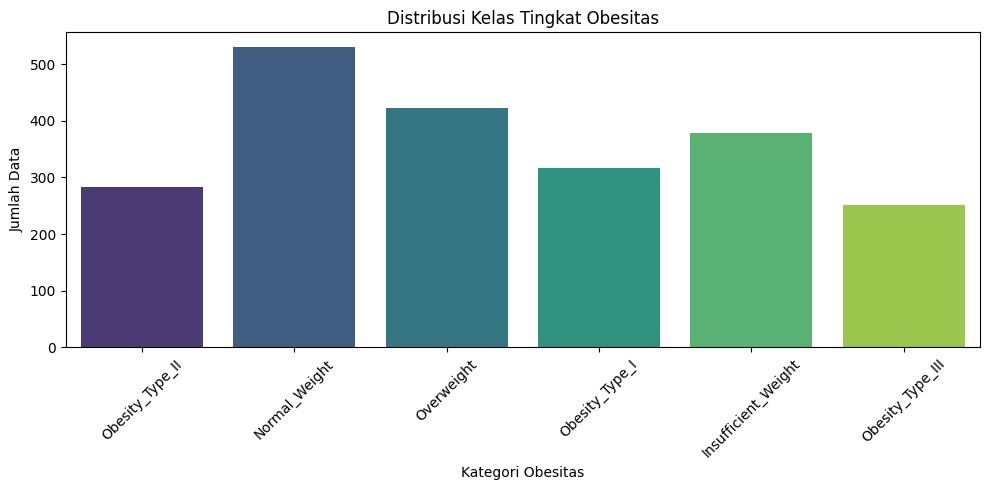


KATEGORI                  | JUMLAH   | RASIO    | STATUS
------------------------------------------------------------
Normal_Weight             | 530      | 1.00     | Mayoritas
Overweight                | 423      | 1.25     | Mayoritas
Insufficient_Weight       | 378      | 1.40     | Mayoritas
Obesity_Type_I            | 317      | 1.67     | Minoritas
Obesity_Type_II           | 283      | 1.87     | Minoritas
Obesity_Type_III          | 251      | 2.11     | Minoritas


In [88]:
# Visualisasi Diagram Batang
plt.figure(figsize=(10, 5))
sns.countplot(x='Obesity level', data=data, palette='viridis')
plt.title('Distribusi Kelas Tingkat Obesitas')
plt.xlabel('Kategori Obesitas')
plt.ylabel('Jumlah Data')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# Tabel 
print("\n" + "="*60)
print(f"{'KATEGORI':<25} | {'JUMLAH':<8} | {'RASIO':<8} | {'STATUS'}")
print("-" * 60)

# target jumlah kelas terbanyak
jumlah_terbanyak = data['Obesity level'].value_counts().max()

for kategori, jumlah in data['Obesity level'].value_counts().items():
    rasio = jumlah_terbanyak / jumlah
    status = "Minoritas" if rasio > 1.5 else "Mayoritas"
    print(f"{kategori:<25} | {jumlah:<8} | {rasio:<8.2f} | {status}")
print("="*60)

# Preprocessing data

In [89]:
# . Label Encoding
label_mappings = {
    "Gender": {"Female": 0, "Male": 1},
    "Family history of overweight": {"No": 0, "Yes": 1},
    "High caloric food consumption": {"No": 0, "Yes": 1},
    "Smoking": {"No": 0, "Yes": 1},
    "Monitor calories": {"No": 0, "Yes": 1}
}
for col, mapping in label_mappings.items():
    data[col] = data[col].map(mapping)

# Ordinal Encoding
ordinal_mappings = {
    "Vegetable consumption frequency": {"Never": 0, "Sometimes": 1, "Always": 2},
    "Daily main meals frequency": {"Between 1-2": 0, "Three": 1, "More than Three": 2},
    "Between-meal food consumption frequency": {"No": 0, "Sometimes": 1, "Frequently": 2, "Always": 3},
    "Alcohol intake": {"I do not drink": 0, "Sometimes": 1, "Frequently": 2, "Always": 3},
    "Daily water intake": {"Less than a liter": 0, "Between 1 and 2 L": 1, "More than 2 L": 2},
    "Physical exercise": {"I do not have": 0, "1 or 2 days": 1, "2 or 4 days": 2, "4 or 5 days": 3, "Almost Everyday": 4},
    "Daily device usage duration": {"0-2 hours": 0, "3-5 hours": 1, "More than 5 hours": 2},
    "Mode of transportation": {"Walking": 0, "Bike": 1, "Rickshaw": 2, "Public Transportation": 3, "Private Car": 4},
    "Obesity level": {"Insufficient_Weight": 0, "Normal_Weight": 1, "Overweight": 2, "Obesity_Type_I": 3, "Obesity_Type_II": 4, "Obesity_Type_III": 5}
}
for col, mapping in ordinal_mappings.items():
    data[col] = data[col].map(mapping)

display(data.head())

,Gender,Age,Height (m),Weight (kg),Family history of overweight,High caloric food consumption,Vegetable consumption frequency,Daily main meals frequency,Between-meal food consumption frequency,Smoking,Alcohol intake,Daily water intake,Monitor calories,Physical exercise,Daily device usage duration,Mode of transportation,Obesity level
0,1,29,1.65,101.0,1,1,1,1,2,0,0,1,0,0,2,4,4
1,0,25,1.65,53.0,0,0,2,1,3,0,0,1,0,4,2,3,1
2,1,23,1.70,70.0,0,0,2,0,1,1,1,0,0,0,2,3,1
3,1,22,1.68,112.0,1,1,1,1,2,0,0,1,0,0,2,3,4
4,1,19,1.75,67.0,0,1,2,1,1,1,0,1,0,2,1,1,1


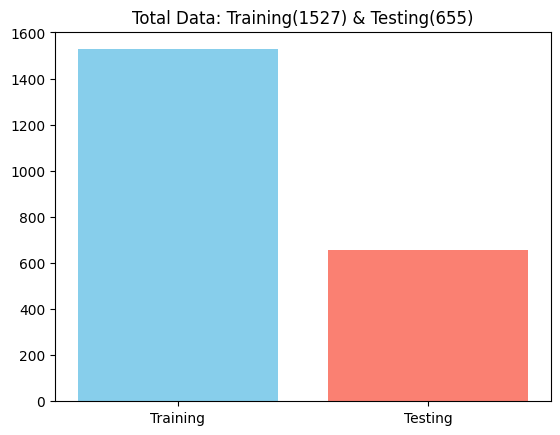

Total Training: 1527
Total Testing: 655


In [90]:
X = data.drop("Obesity level", axis=1)
y = data["Obesity level"]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

# diagram
counts = [len(X_train), len(X_test)]
plt.bar(['Training', 'Testing'], counts, color=['skyblue', 'salmon'])
plt.title(f"Total Data: Training({counts[0]}) & Testing({counts[1]})")
plt.show()

print(f"Total Training: {counts[0]}")
print(f"Total Testing: {counts[1]}")

C:\Users\hp\AppData\Local\Temp\ipykernel_4444\2197276207.py:23: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x=y_train, palette='viridis')
C:\Users\hp\AppData\Local\Temp\ipykernel_4444\2197276207.py:31: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x=y_train_res, palette='viridis')


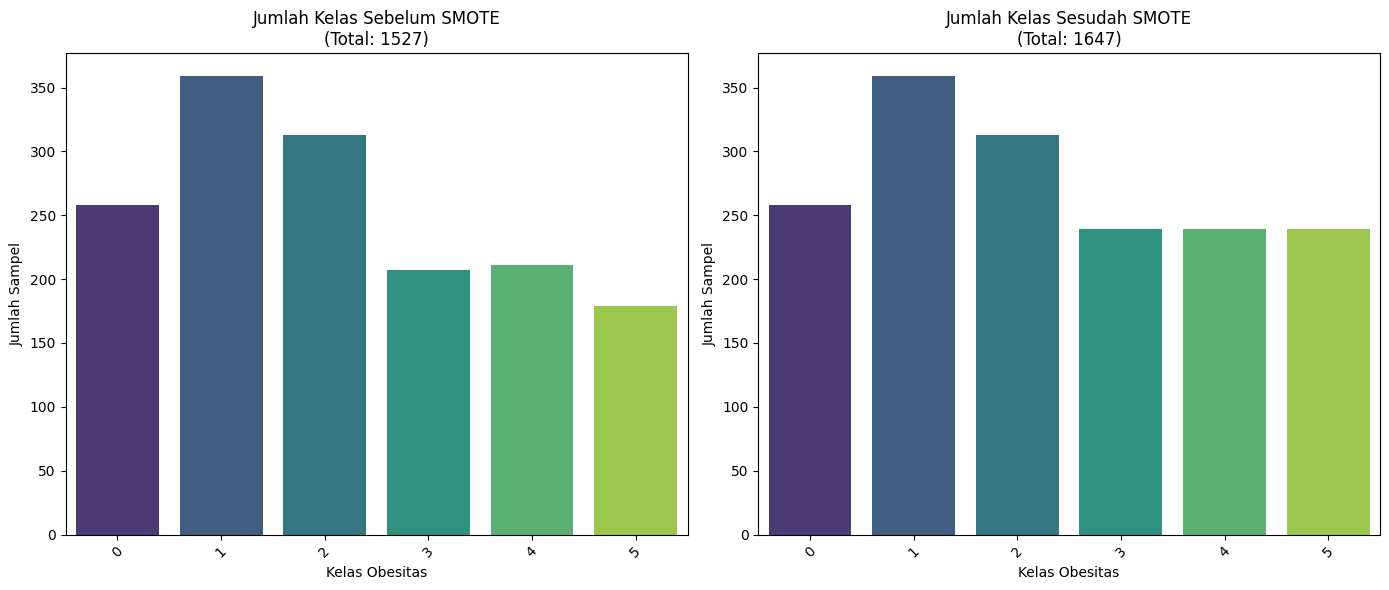

DETAIL PERUBAHAN JUMLAH DATA SETIAP KELAS

[SEBELUM SMOTE]
Kelas 0                    | Jumlah: 258      | Rasio: 1.39    
Kelas 1                    | Jumlah: 359      | Rasio: 1.00    
Kelas 2                    | Jumlah: 313      | Rasio: 1.15    
Kelas 3                    | Jumlah: 207      | Rasio: 1.73    
Kelas 4                    | Jumlah: 211      | Rasio: 1.70    
Kelas 5                    | Jumlah: 179      | Rasio: 2.01    

[SESUDAH SMOTE]
Kelas 0                    | Jumlah: 258      | Rasio: 1.39    
Kelas 1                    | Jumlah: 359      | Rasio: 1.00    
Kelas 2                    | Jumlah: 313      | Rasio: 1.15    
Kelas 3                    | Jumlah: 239      | Rasio: 1.50    
Kelas 4                    | Jumlah: 239      | Rasio: 1.50    
Kelas 5                    | Jumlah: 239      | Rasio: 1.50    
--------------------------------------------------
Data Testing (Tetap Asli): 655


In [91]:
# jumlah kelas mayoritas
jumlah_terbanyak = pd.Series(y_train).value_counts().max()

# kelas yang akan di-oversample mencapai rasio < 1.5
sampling_strategy = {}

# Menentukan jumlah data sintetis yang diperlukan untuk setiap kelas minoritas
for kategori, jumlah in pd.Series(y_train).value_counts().items():
    rasio = jumlah_terbanyak / jumlah
    # tambahkan data untuk kelas rasio lebih besar dari 1.5
    if rasio > 1.5:
        target_oversample = int(jumlah_terbanyak / 1.5)  
        sampling_strategy[kategori] = target_oversample

smote = SMOTE(sampling_strategy=sampling_strategy, random_state=42)
X_train_res, y_train_res = smote.fit_resample(X_train, y_train)

# Visualisasi
plt.figure(figsize=(14, 6))

# Sebelum smote
plt.subplot(1, 2, 1)
sns.countplot(x=y_train, palette='viridis')
plt.title(f'Jumlah Kelas Sebelum SMOTE\n(Total: {len(y_train)})')
plt.xticks(rotation=45)
plt.xlabel('Kelas Obesitas')
plt.ylabel('Jumlah Sampel')

# Sesudah smote
plt.subplot(1, 2, 2)
sns.countplot(x=y_train_res, palette='viridis')
plt.title(f'Jumlah Kelas Sesudah SMOTE\n(Total: {len(y_train_res)})')
plt.xticks(rotation=45)
plt.xlabel('Kelas Obesitas')
plt.ylabel('Jumlah Sampel')

plt.tight_layout()
plt.show()

# Detail jumlah data
print("="*50)
print("DETAIL PERUBAHAN JUMLAH DATA SETIAP KELAS")
print("="*50)

# Sebelum SMOTE: Tambahkan rasio
print("\n[SEBELUM SMOTE]")
before_smote_counts = pd.Series(y_train).value_counts().sort_index()
for kategori, jumlah in before_smote_counts.items():
    rasio = jumlah_terbanyak / jumlah
    print(f"Kelas {kategori:<20} | Jumlah: {jumlah:<8} | Rasio: {rasio:<8.2f}")

# Setelah SMOTE: Tambahkan rasio
print("\n[SESUDAH SMOTE]")
after_smote_counts = pd.Series(y_train_res).value_counts().sort_index()
for kategori, jumlah in after_smote_counts.items():
    rasio = jumlah_terbanyak / jumlah
    print(f"Kelas {kategori:<20} | Jumlah: {jumlah:<8} | Rasio: {rasio:<8.2f}")

print("-" * 50)
print(f"Data Testing (Tetap Asli): {X_test.shape[0]}")

In [92]:
from sklearn.feature_selection import f_classif

# Hitung ANOVA
f_values, p_values = f_classif(X_train_res, y_train_res)

anova_df = pd.DataFrame({
    'Fitur': X_train_res.columns,
    'F_Score': f_values,
    'P_Value': p_values
})

# P-Value < 0.05 dan urut dari F-Score tertinggi
selected_anova = anova_df[anova_df['P_Value'] < 0.05].sort_values(by='F_Score', ascending=False)
features_sorted = selected_anova['Fitur'].tolist()

selected_anova['P_Value'] = selected_anova['P_Value'].apply(lambda x: f"{x:.10f}")
print(f"Ditemukan {len(features_sorted)} fitur relevan (p < 0.05).")
print("Ranking Fitur Berdasarkan F_Score:")
# print(selected_anova[['Fitur', 'F_Score']])
print(selected_anova[['Fitur', 'P_Value', 'F_Score']].to_string(index=False))

Ditemukan 16 fitur relevan (p < 0.05).
Ranking Fitur Berdasarkan F_Score:
                                  Fitur      P_Value     F_Score
                            Weight (kg) 0.0000000000 1184.866407
Between-meal food consumption frequency 0.0000000000  207.701591
          High caloric food consumption 0.0000000000  128.970326
        Vegetable consumption frequency 0.0000000000   91.877069
                      Physical exercise 0.0000000000   66.605720
             Daily main meals frequency 0.0000000000   65.614048
                             Height (m) 0.0000000000   63.024518
           Family history of overweight 0.0000000000   53.768777
                 Mode of transportation 0.0000000000   30.436413
                                    Age 0.0000000000   28.473580
                                Smoking 0.0000000000   14.511661
                         Alcohol intake 0.0000000000   13.903874
                       Monitor calories 0.0000000002   10.927332
                

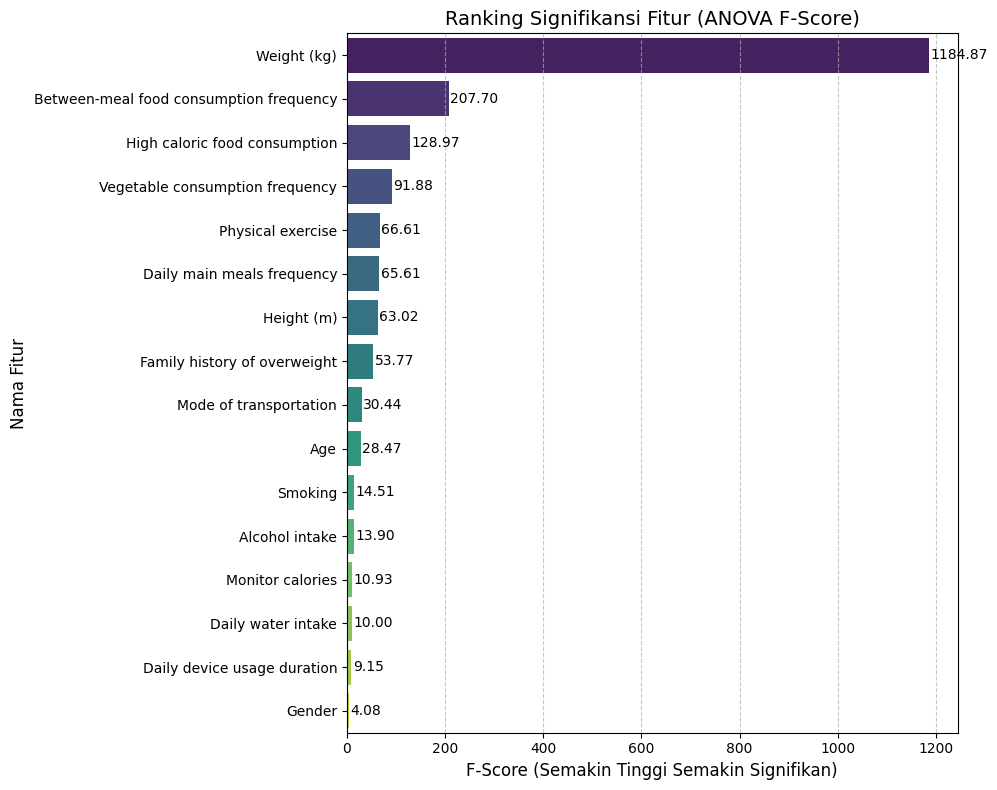

In [93]:
# --- 3. Tambahan Visualisasi: Bar Chart F-Score ---
plt.figure(figsize=(10, 8))
sns.barplot(x='F_Score', y='Fitur', data=selected_anova, palette='viridis', hue='Fitur', legend=False)

plt.title('Ranking Signifikansi Fitur (ANOVA F-Score)', fontsize=14)
plt.xlabel('F-Score (Semakin Tinggi Semakin Signifikan)', fontsize=12)
plt.ylabel('Nama Fitur', fontsize=12)
plt.grid(axis='x', linestyle='--', alpha=0.7)

# Tambahkan label nilai F-Score di ujung batang
for i, v in enumerate(selected_anova['F_Score']):
    plt.text(v + 3, i, f'{v:.2f}', va='center', fontsize=10)

plt.tight_layout()
plt.show()

In [94]:
# IFS: Membuat Subset Fitur
subset_list = []  # Menyimpan semua subset fitur
print("=== IFS: Membuat Subset Fitur ===")
for i in range(1, len(features_sorted) + 1):
    current_subset = features_sorted[:i]
    subset_list.append(current_subset)
    print(f"Iter {i}: Subset Fitur -> {current_subset}")

=== IFS: Membuat Subset Fitur ===
Iter 1: Subset Fitur -> ['Weight (kg)']
Iter 2: Subset Fitur -> ['Weight (kg)', 'Between-meal food consumption frequency']
Iter 3: Subset Fitur -> ['Weight (kg)', 'Between-meal food consumption frequency', 'High caloric food consumption']
Iter 4: Subset Fitur -> ['Weight (kg)', 'Between-meal food consumption frequency', 'High caloric food consumption', 'Vegetable consumption frequency']
Iter 5: Subset Fitur -> ['Weight (kg)', 'Between-meal food consumption frequency', 'High caloric food consumption', 'Vegetable consumption frequency', 'Physical exercise']
Iter 6: Subset Fitur -> ['Weight (kg)', 'Between-meal food consumption frequency', 'High caloric food consumption', 'Vegetable consumption frequency', 'Physical exercise', 'Daily main meals frequency']
Iter 7: Subset Fitur -> ['Weight (kg)', 'Between-meal food consumption frequency', 'High caloric food consumption', 'Vegetable consumption frequency', 'Physical exercise', 'Daily main meals frequency', 

In [95]:
# RANDOM FOREST: Evaluasi Subset Fitur
ifs_results = []
all_fold_details = []

print("\n RANDOM FOREST: Evaluasi Subset Fitur ")
print(f"{'Iter':<4} | {'Jml':<3} | {'Acc (%)':<8} | {'Detail per Fold (Raw Score)':<35} | {'Kombinasi Fitur'}")
print("-" * 120)

for i, current_subset in enumerate(subset_list, 1):
    X_train_sub = X_train_res[current_subset]

    # Evaluasi dengan Random Forest
    rf_base = RandomForestClassifier(n_estimators=100, random_state=42)
    cv = KFold(n_splits=10, shuffle=True, random_state=42)
    cv_scores = cross_val_score(rf_base, X_train_sub, y_train_res, cv=cv)
    mean_acc = cv_scores.mean()
    
    ifs_results.append(mean_acc)
    all_fold_details.append(cv_scores)

    # Format untuk tampilan
    fold_str = ", ".join([f"{s:.4f}" for s in cv_scores])
    subset_str = ", ".join(current_subset)
    print(f"{i:<4} | {len(current_subset):<3} | {mean_acc*100:<8.2f} | [{fold_str}] | {subset_str}")


best_acc = max(ifs_results)
best_index = ifs_results.index(best_acc)
best_subset = subset_list[best_index]

print("-" * 120)
print("KESIMPULAN AKHIR:")
print(f"Akurasi Tertinggi: {best_acc*100:.2f}%")
print(f"Jumlah Fitur     : {len(best_subset)}")
print(f"Subset Fitur     : {best_subset}")


 RANDOM FOREST: Evaluasi Subset Fitur 
Iter | Jml | Acc (%)  | Detail per Fold (Raw Score)         | Kombinasi Fitur
------------------------------------------------------------------------------------------------------------------------
1    | 1   | 56.34    | [0.5636, 0.5636, 0.6121, 0.5879, 0.5758, 0.5394, 0.6061, 0.5793, 0.4878, 0.5183] | Weight (kg)
2    | 2   | 58.95    | [0.5636, 0.6000, 0.5879, 0.5758, 0.5879, 0.6121, 0.6485, 0.5488, 0.6159, 0.5549] | Weight (kg), Between-meal food consumption frequency
3    | 3   | 60.11    | [0.5879, 0.6485, 0.6000, 0.6000, 0.5515, 0.6303, 0.6061, 0.6037, 0.6280, 0.5549] | Weight (kg), Between-meal food consumption frequency, High caloric food consumption
4    | 4   | 63.87    | [0.6485, 0.6424, 0.6364, 0.6788, 0.6121, 0.6545, 0.5879, 0.6951, 0.6280, 0.6037] | Weight (kg), Between-meal food consumption frequency, High caloric food consumption, Vegetable consumption frequency
5    | 5   | 66.12    | [0.7030, 0.6424, 0.6667, 0.6848, 0.6364, 0.

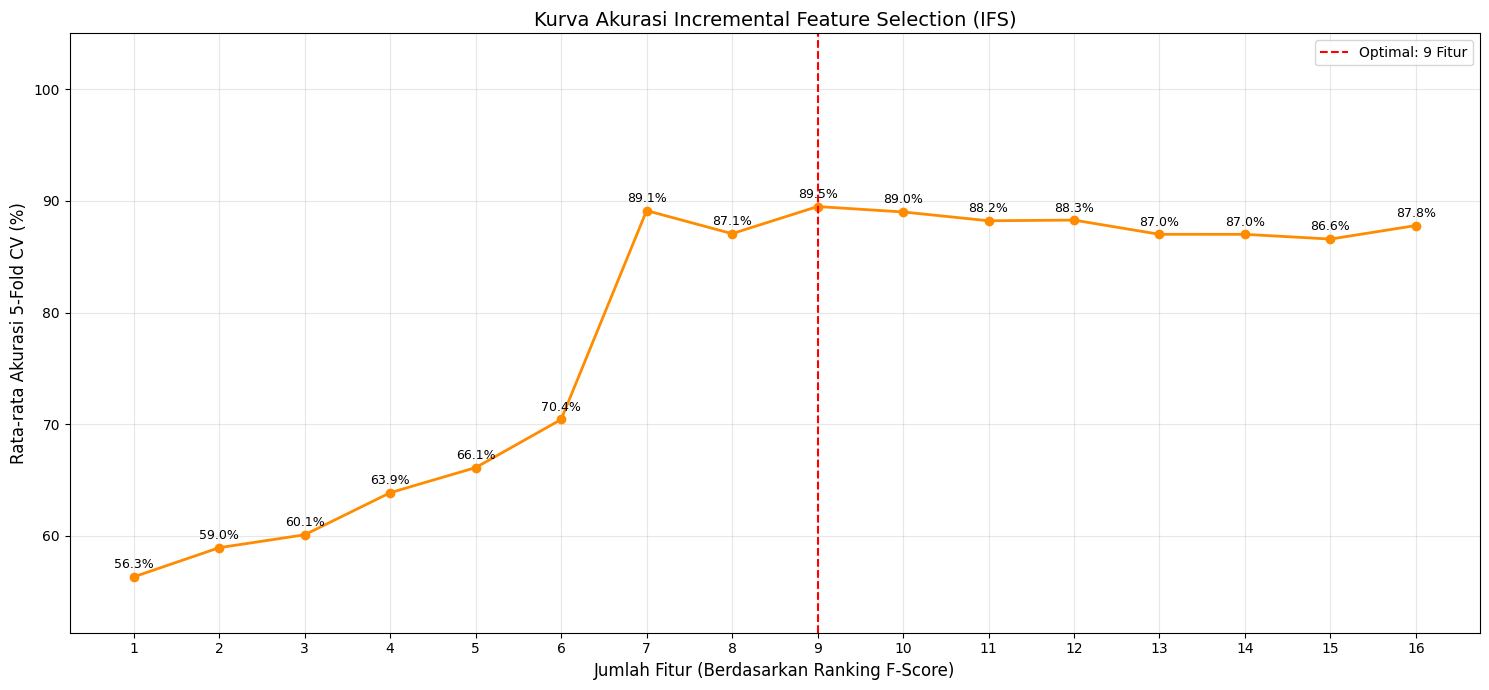

In [96]:
plt.figure(figsize=(15, 7))
x_values = range(1, len(features_sorted) + 1)
y_values = [acc * 100 for acc in ifs_results]

plt.plot(x_values, y_values, marker='o', color='darkorange', linewidth=2)
# Garis fitur terbaik
plt.axvline(x=len(best_subset), color='red', linestyle='--', label=f'Optimal: {len(best_subset)} Fitur')
# Teks akurasi
for x, y in zip(x_values, y_values):
    plt.text(x, y + 0.5, f'{y:.1f}%', ha='center', va='bottom', fontsize=9)

# Pengaturan tampilan
plt.xticks(x_values)
plt.title('Kurva Akurasi Incremental Feature Selection (IFS)', fontsize=14)
plt.xlabel('Jumlah Fitur (Berdasarkan Ranking F-Score)', fontsize=12)
plt.ylabel('Rata-rata Akurasi 5-Fold CV (%)', fontsize=12)
plt.legend()
plt.grid(True, alpha=0.3)
plt.ylim(min(y_values) - 5, 105)
plt.tight_layout()
plt.show()

HASIL AKHIR SKENARIO 2 (Menggunakan ANOVA + IFS)
Jumlah Fitur : 9
Fitur yang digunakan   : ['Weight (kg)', 'Between-meal food consumption frequency', 'High caloric food consumption', 'Vegetable consumption frequency', 'Physical exercise', 'Daily main meals frequency', 'Height (m)', 'Family history of overweight', 'Mode of transportation']
Akurasi Data Testing  : 88.70%
--------------------------------------------------

Laporan Klasifikasi Akhir (Evaluasi pada Data Asli):
               precision    recall  f1-score   support

           0       0.94      0.92      0.93       120
           1       0.90      0.89      0.90       171
           2       0.78      0.91      0.84       110
           3       0.88      0.80      0.84       110
           4       0.89      0.90      0.90        72
           5       0.97      0.92      0.94        72

    accuracy                           0.89       655
   macro avg       0.89      0.89      0.89       655
weighted avg       0.89      0.89 

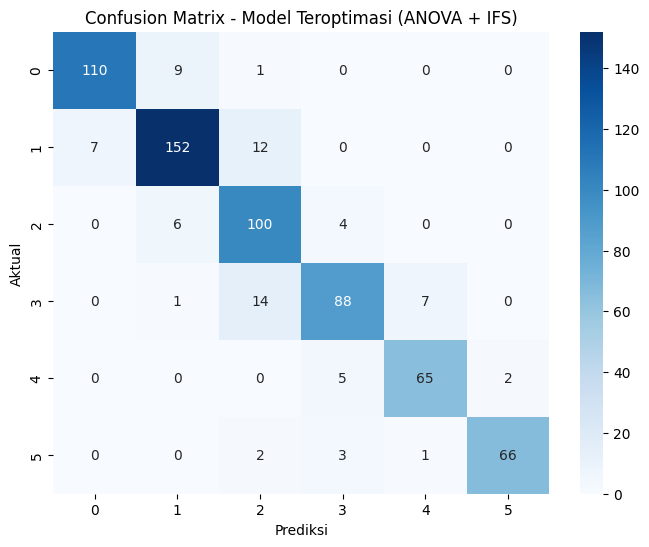

In [97]:
# final_rf = RandomForestClassifier(random_state=42, n_estimators=100)
rf_base.fit(X_train_res[best_subset], y_train_res)
y_pred_final = rf_base.predict(X_test[best_subset])

print("="*50)
print("HASIL AKHIR SKENARIO 2 (Menggunakan ANOVA + IFS)")
print("="*50)
print(f"Jumlah Fitur : {len(best_subset)}")
print(f"Fitur yang digunakan   : {best_subset}")
print(f"Akurasi Data Testing  : {accuracy_score(y_test, y_pred_final)*100:.2f}%")
print("-" * 50)
print("\nLaporan Klasifikasi Akhir (Evaluasi pada Data Asli):\n", classification_report(y_test, y_pred_final))

#confusion matriks
plt.figure(figsize=(8,6))
sns.heatmap(confusion_matrix(y_test, y_pred_final), annot=True, fmt='d', cmap='Blues')
plt.xlabel('Prediksi')
plt.ylabel('Aktual')
plt.title('Confusion Matrix - Model Teroptimasi (ANOVA + IFS)')
plt.show()

In [98]:
import pickle

# Simpan model
with open('rf_model_skenario2.pkl', 'wb') as file:
    pickle.dump(rf_base, file)